# W17 · Sim2Real III：系统辨识与 Sim2Real 评估协议

> 阶段二（M5–M6）：MotrixLab —— 国产 Sim2Real 能力 · 第 5/6 讲

前两讲我们「把训练分布加宽」来容忍误差（DR、噪声/延迟注入）。本讲讲另一条腿：
**系统辨识（System Identification, SysID）**——动手测量真实系统的参数，从源头把
仿真建准，把 DR 需要覆盖的范围收窄。后半讲解决一个更工程的问题：
**如何设计一份让人信服的 Sim2Real 评估协议**——你的策略到底「多鲁棒」，要用数据说话。

## 学习目标

1. 说出 SysID 与 DR 的互补关系，以及 real-to-sim-to-real 的完整闭环；
2. 把参数辨识写成优化问题 $\hat\theta = \arg\min_\theta \sum_t \lVert x^{\text{sim}}_t(\theta) - x^{\text{real}}_t \rVert^2$ 并实现它；
3. 理解**可辨识性**：为什么自由衰减实验辨识不出全部参数，必须施加已知激励；
4. 用批量向量化仿真在参数网格上高效搜索（复用 W13 的并行思想）；
5. 设计分层 Sim2Real 评估协议（标称 → 参数扰动 → 观测噪声 → 组合压力），输出标准化报告。

> **本讲可执行性说明**：全部内容为纯 numpy/pandas 实验，可真实执行。
> 我们用「合成真机」做实验——先造一个参数未知的仿真系统充当「真实世界」，
> 这是 SysID 教学的标准做法，方法本身与真机完全同构。

## 5.1 SysID 的直觉：给仿真器「校准」

DR 像「买大一号的衣服」——不管什么身材都能穿，但不合身；SysID 像「量体裁衣」——
先量准尺寸，衣服可以做得刚好。工程上的最佳实践是**两者叠加**：

$$
\text{SysID 给出标称值 } \hat\theta \text{ 与不确定度 } \pm\delta
\;\Rightarrow\; \text{DR 在 } [\hat\theta - \delta,\; \hat\theta + \delta] \text{ 内随机化}
$$

完整闭环被称为 **real-to-sim-to-real**：

```
真实机器人 ──采集数据──▶ 系统辨识 ──校准参数──▶ 仿真器
    ▲                                              │
    └────────────── 部署加固后的策略 ◀── DR 训练 ◀──┘
```

SysID 在控制学科里是成熟领域（《自动控制原理》里的阶跃响应法、最小二乘辨识都是）。
机器人 RL 里的 SysID 没有新魔法，难在**对象复杂**：接触摩擦、执行器串联动态、
减速器间隙……本讲先用一个弹簧-阻尼振子把完整流程走通。

## 5.2 问题形式化与一个陷阱：可辨识性

考虑弹簧-阻尼-质量振子（机器人单关节的最低阶近似）：

$$
m\ddot{x} + c\dot{x} + kx = F(t), \qquad \theta = (m, c, k)
$$

参数辨识即最小化仿真轨迹与实测轨迹的误差：

$$
\hat\theta = \arg\min_\theta \; \sum_{t=0}^{T} \left\lVert
x^{\text{sim}}_t(\theta) - x^{\text{real}}_t \right\rVert^2
$$

**一个容易踩的陷阱**：如果只做「自由衰减」实验（$F=0$，给个初始位移松手），
方程是齐次的——$(m, c, k)$ 同乘任意系数 $\alpha$，轨迹**完全不变**！
也就是说自由衰减里只能辨识出两个组合量：振荡频率 $\omega=\sqrt{k/m}$ 与
衰减率 $c/(2m)$，三个参数的绝对值永远差一个自由度。这叫**不可辨识方向**。

解法朴素而深刻：**施加一个大小已知的激励**。本讲用阶跃力 $F=2\,\text{N}$——
稳态位移 $x_\infty = F/k$ 直接钉住 $k$，频率钉住 $m$，衰减钉住 $c$，
三个参数全部可辨识。真机 SysID 设计激励信号（阶跃/扫频/PRBS）时，
考量的正是同一件事：**让被辨识的动态在数据里留下足够强的「指纹」**。

工程上这个优化**没有解析梯度**（仿真是黑盒），这正是批量并行仿真的用武之地：
在参数网格上同时仿真数千组候选（W13 的向量化技巧），一次性算完所有 loss。

### 第一步：造一台「真实设备」并做阶跃响应实验

用一个参数保密的振子充当真实世界。真机上你能做的也就是：施加一个已知大小的
恒定力（或电流指令），用位置传感器记录响应——我们从这条曲线反推 $(m, c, k)$。

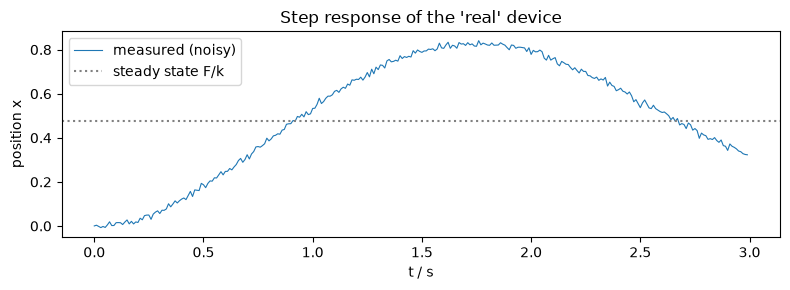

采集完成：300 个采样点 @ 100 Hz，传感器噪声 σ = 0.01，激励 F = 2.0 N


In [1]:
import matplotlib.pyplot as plt
import numpy as np

DT = 0.01          # 采样周期 10 ms（100 Hz，典型编码器量级）
T = 3.0            # 采集 3 秒
N = int(T / DT)
t = np.arange(N) * DT

# ===== “真实系统”参数（对辨识算法保密，仅最后用于对答案） =====
TRUE = dict(m=1.30, c=0.45, k=4.20)
F = 2.0            # 已知阶跃力（N）—— 激励大小必须是已知量，否则参数不可辨识
NOISE_STD = 0.01   # 位置传感器噪声（1 cm 量级，典型的低成本测距/编码误差）

def simulate(m, c, k, x0=0.0, v0=0.0):
    '''半隐式欧拉积分：m x'' + c x' + k x = F；标量或向量化参数均可'''
    shape = np.broadcast_shapes(np.shape(m), np.shape(c), np.shape(k))
    x = np.full(shape or (), x0, dtype=float)
    v = np.zeros_like(x)
    xs = np.empty((N,) + x.shape)
    for i in range(N):
        v += (F - c * v - k * x) / m * DT
        x += v * DT
        xs[i] = x
    return xs

# 采集“真实”数据：阶跃响应真值 + 传感器噪声
rng = np.random.default_rng(7)
x_real = simulate(TRUE["m"], TRUE["c"], TRUE["k"]) + rng.normal(0, NOISE_STD, N)

plt.figure(figsize=(8, 3))
plt.plot(t, x_real, lw=0.8, label="measured (noisy)")
plt.axhline(F / TRUE["k"], color="gray", ls=":", label="steady state F/k")
plt.xlabel("t / s"); plt.ylabel("position x"); plt.legend()
plt.title("Step response of the 'real' device")
plt.tight_layout(); plt.show()
print(f"采集完成：{N} 个采样点 @ {1 / DT:.0f} Hz，传感器噪声 σ = {NOISE_STD}，激励 F = {F} N")

从这条阶跃响应里，有经验的同学已能读出全部三个参数的「指纹」：
稳态值 $\approx 0.48 = F/k$；振荡频率约 $0.9$ Hz $\to \sqrt{k/m}/(2\pi)$；
包络衰减速度反映阻尼比 $c/(2\sqrt{mk})$。

### 第二步：网格搜索 —— 一次向量化仿真评估 27,000 组参数

In [2]:
# 候选参数网格：m × c × k = 30 × 30 × 30 = 27,000 组
m_grid = np.linspace(0.5, 2.5, 30)
c_grid = np.linspace(0.05, 1.0, 30)
k_grid = np.linspace(2.0, 7.0, 30)
M, C, K = np.meshgrid(m_grid, c_grid, k_grid, indexing="ij")
candidates = np.stack([M.ravel(), C.ravel(), K.ravel()], axis=1)  # (27000, 3)
print(f"候选参数组数：{len(candidates)}")

# 向量化批量仿真：所有候选同时积分（这就是 W13 批量 SceneData 的思想）
x_sims = simulate(candidates[:, 0], candidates[:, 1], candidates[:, 2])  # (N, 27000)

# 每个候选的轨迹误差（MSE）
losses = ((x_sims - x_real[:, None]) ** 2).mean(axis=0)
best = int(np.argmin(losses))
print(f"网格最优：m={candidates[best][0]:.3f}, c={candidates[best][1]:.3f}, "
      f"k={candidates[best][2]:.3f}  (MSE={losses[best]:.5f})")
print(f"真实值  ：m={TRUE['m']:.3f}, c={TRUE['c']:.3f}, k={TRUE['k']:.3f}")

候选参数组数：27000
网格最优：m=1.328, c=0.410, k=4.241  (MSE=0.00010)
真实值  ：m=1.300, c=0.450, k=4.200


网格搜索给出粗定位，再在最优点附近做两轮 coarse-to-fine 细化，
并画出 loss 曲面看「参数指纹」的形状。

辨识结果：m=1.288, c=0.466, k=4.191
真实值  ：m=1.300, c=0.450, k=4.200
参数误差：m 1.0%, c 3.6%, k 0.2%


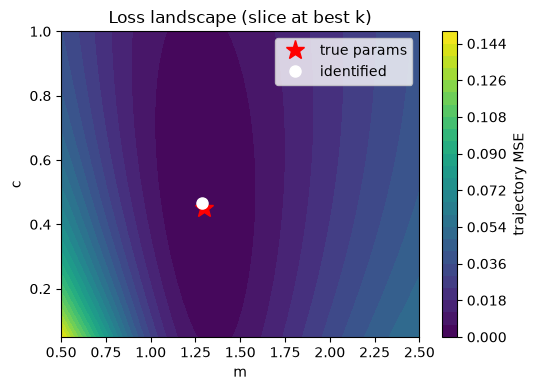

In [3]:
# 细化：在最优点附近做更密的局部网格（两轮 coarse-to-fine）
est = candidates[best].copy()
for _ in range(2):
    span = np.array([0.2, 0.08, 0.5])
    mg = np.linspace(est[0] - span[0], est[0] + span[0], 21)
    cg = np.linspace(max(est[1] - span[1], 0.01), est[1] + span[1], 21)
    kg = np.linspace(est[2] - span[2], est[2] + span[2], 21)
    M, C, K = np.meshgrid(mg, cg, kg, indexing="ij")
    cand = np.stack([M.ravel(), C.ravel(), K.ravel()], axis=1)
    ls = ((simulate(cand[:, 0], cand[:, 1], cand[:, 2]) - x_real[:, None]) ** 2).mean(axis=0)
    est = cand[int(np.argmin(ls))]

print(f"辨识结果：m={est[0]:.3f}, c={est[1]:.3f}, k={est[2]:.3f}")
print(f"真实值  ：m={TRUE['m']:.3f}, c={TRUE['c']:.3f}, k={TRUE['k']:.3f}")
print(f"参数误差：m {abs(est[0] - TRUE['m']) / TRUE['m']:.1%}, "
      f"c {abs(est[1] - TRUE['c']) / TRUE['c']:.1%}, "
      f"k {abs(est[2] - TRUE['k']) / TRUE['k']:.1%}")

# loss 曲面切片（k 固定在最优）：看 m-c 平面上误差山谷的形状
mg = np.linspace(0.5, 2.5, 60)
cg = np.linspace(0.05, 1.0, 60)
M, C = np.meshgrid(mg, cg, indexing="ij")
ls = ((simulate(M.ravel(), C.ravel(), np.full(M.size, est[2])) - x_real[:, None]) ** 2).mean(axis=0)
plt.figure(figsize=(5.5, 4))
plt.contourf(M, C, ls.reshape(60, 60), levels=25, cmap="viridis")
plt.colorbar(label="trajectory MSE")
plt.plot(TRUE["m"], TRUE["c"], "r*", ms=14, label="true params")
plt.plot(est[0], est[1], "wo", ms=8, label="identified")
plt.xlabel("m"); plt.ylabel("c"); plt.legend()
plt.title("Loss landscape (slice at best k)")
plt.tight_layout(); plt.show()

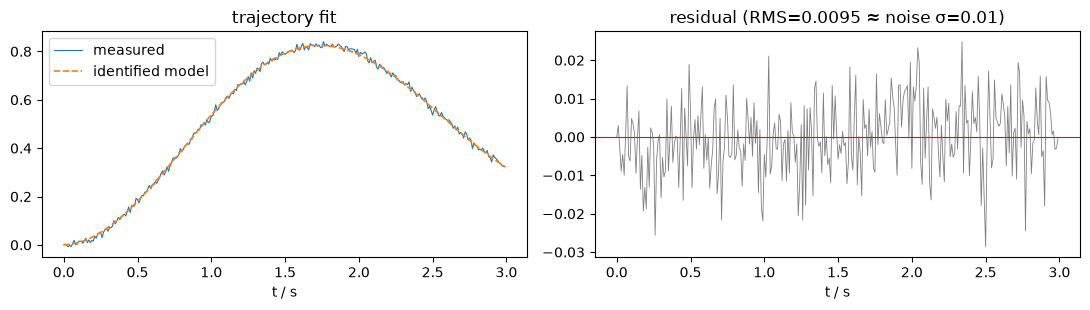

In [4]:
# 最终校验：用辨识参数回放仿真，与“真实”轨迹对比
x_est = simulate(*est)
resid = x_real - x_est

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(t, x_real, lw=0.8, label="measured")
axes[0].plot(t, x_est, "--", lw=1.2, label="identified model")
axes[0].legend(); axes[0].set_xlabel("t / s"); axes[0].set_title("trajectory fit")
axes[1].plot(t, resid, lw=0.6, color="gray")
axes[1].axhline(0, color="r", lw=0.8)
axes[1].set_xlabel("t / s")
axes[1].set_title(f"residual (RMS={resid.std():.4f} ≈ noise σ={NOISE_STD})")
plt.tight_layout(); plt.show()

辨识精度应该落在个位数百分比。两个值得记住的判据：

1. **残差应接近白噪声**（RMS ≈ 传感器 σ）。若残差里有结构化成分（周期信号、趋势），
   说明模型结构缺项（如库仑摩擦、间隙）——**残差诊断是判断「模型结构够不够」的镜子**；
   此时再准的参数优化也补不上结构缺口。
2. **Loss 曲面若出现狭长山谷**，说明存在弱可辨识方向（参数耦合）——山谷里所有点
   轨迹都拟合得很好，但参数本身可能偏。对策：多种激励、多段轨迹联合辨识。

真机上辨识什么、怎么辨识：

| 参数 | 激励信号 | 数据来源 |
|------|----------|----------|
| 质量/质心 | 静态称重 + 双摆摆动周期 | 秤、IMU |
| 关节摩擦（粘性+库仑） | 匀速/变速正弦转动 | 编码器 + 电流（力矩） |
| 电枢惯量 | 阶跃响应的上升时间 | 编码器 |
| 执行器增益/延迟 | 阶跃响应、扫频 | 指令-响应时间戳对比 |
| 足底摩擦系数 | 斜坡滑移临界角 | 倾角计 |

## 5.3 Sim2Real 评估协议设计

「我的策略很鲁棒」不是结论，**协议 + 数据**才是。一份合格的 Sim2Real 评估协议要回答四个问题：
测什么场景、测多少次、报告什么统计量、通过标准是什么。

**分层压力测试**（从易到难，逐级加压）：

| 层级 | 场景 | 模拟的现实 |
|------|------|-----------|
| L0 标称 | 训练参数原样 | sanity check（过不了 L0 说明训练本身失败） |
| L1 参数扰动 | SysID 不确定度边界（如 m ±20%） | 参数偏差 |
| L2 信息通道 | 观测噪声 / 偏置 / 动作延迟 | 传感器与通信现实 |
| L3 组合压力 | L1 × L2 同时施加 | 真机的常态：所有误差同时存在 |
| L4 OOD 探测 | 超出 DR 范围的参数 | 摸底策略的能力边界（**不要求通过，只要求知道**） |

**统计规范**：每个场景 ≥20 个 episode、固定种子列表、报告均值 ± 标准差与最差案例
（min 往往比 mean 更接近真机体验）；所有场景共用同一份评估代码与随机种子，保证可复现。

下面实现一个最小可用的协议评估器。被评对象不用 RL 策略，而用你们熟悉的 **PD 控制器**
跟踪振子的阶跃目标——评估协议与被评对象无关，这套代码下个 notebook 直接复用给 RL 策略。

In [5]:
import pandas as pd

def pd_tracking_rollout(m, c, k, kp=400.0, kd=36.0, x_target=1.0,
                        noise_std=0.0, T=5.0, seed=0):
    '''PD 控制振子跟踪阶跃目标；返回 (时间, 位置)。
    控制器增益按辨识得到的“标称模型”设计，被控对象参数 (m,c,k) 可偏离标称。
    '''
    rng = np.random.default_rng(seed)
    n = int(T / DT)
    x, v = 0.0, 0.0
    xs = np.empty(n)
    for i in range(n):
        x_meas = x + rng.normal(0, noise_std)      # 传感器噪声
        u = kp * (x_target - x_meas) - kd * v
        v += (u - c * v - k * x) / m * DT           # 被控对象动力学
        x += v * DT
        xs[i] = x
    return np.arange(n) * DT, xs

def metrics(xs, x_target=1.0, settle_band=0.02):
    '''标准控制指标：超调量 / 调节时间（2% 带）/ 稳态误差（末 0.5 s 均值）'''
    overshoot = max(0.0, (xs.max() - x_target) / x_target * 100)
    out = np.abs(xs - x_target) > settle_band
    # 最后一次越出 2% 误差带的时刻即调节时间
    settle_t = (len(xs) - np.argmax(out[::-1])) * DT if out.any() else 0.0
    ss_err = abs(xs[int(-0.5 / DT):].mean() - x_target)
    return dict(overshoot_pct=overshoot, settle_time_s=round(settle_t, 2), ss_err=round(ss_err, 4))

# ===== 分层评估协议 =====
scenarios = {
    "L0 nominal":        dict(m=est[0], c=est[1], k=est[2], noise_std=0.0),
    "L1 mass +20%":      dict(m=est[0] * 1.2, c=est[1], k=est[2], noise_std=0.0),
    "L1 damping x3":     dict(m=est[0], c=est[1] * 3, k=est[2], noise_std=0.0),
    "L2 sensor noise":   dict(m=est[0], c=est[1], k=est[2], noise_std=0.02),
    "L3 combined":       dict(m=est[0] * 1.2, c=est[1] * 3, k=est[2], noise_std=0.02),
    "L4 OOD (mass x2)":  dict(m=est[0] * 2.0, c=est[1], k=est[2], noise_std=0.02),
}

rows = []
for name, kw in scenarios.items():
    # 每个场景 20 个种子，报告均值（控制指标对噪声敏感，统计量不可省）
    per_seed = [metrics(pd_tracking_rollout(**kw, seed=s)[1]) for s in range(20)]
    avg = pd.DataFrame(per_seed).mean()
    rows.append(dict(scenario=name, overshoot_pct=round(avg["overshoot_pct"], 1),
                     settle_time_s=round(avg["settle_time_s"], 2),
                     ss_err=round(avg["ss_err"], 4)))

report = pd.DataFrame(rows).set_index("scenario")
report

,overshoot_pct,settle_time_s,ss_err
scenario,,,
L0 nominal,0.0,0.23,0.0104
L1 mass +20%,1.0,0.21,0.0104
L1 damping x3,0.0,0.25,0.0104
L2 sensor noise,0.3,2.65,0.0103
L3 combined,0.7,2.57,0.0103
L4 OOD (mass x2),9.2,2.24,0.0103


这张表就是一份最小评估报告：L0 证明控制器本身调对了；L1/L2 量化单类误差的代价；
L3 逼近真机常态；L4 故意超出设计范围，回答「边界在哪里」。

读表时留意两个细节：(1) 所有场景的稳态误差都钉在 1%——这是纯 PD（无积分环节）
对弹簧负载的**固有静差** $k\,x^*/(k+k_p)$，属于结构性误差，参数扰动几乎不影响它；
(2) 传感器噪声（L2）对调节时间的破坏远大于质量偏差（L1）——测量噪声被 $k_p=400$
的高增益直接放大进控制量，这正是真机上「增益不能无限调高」的原因，也与 W16
「高增益策略对噪声/延迟敏感」的结论互相印证。

**写报告时的常见翻车点**（中级工程师与初学者的分水岭）：

- 只报标称成绩 → 等于没做 Sim2Real 评估；
- 每场景只跑 1 次 → 噪声场景的结果没有统计意义；
- 训练/评估用同一批种子 → 相当于「考题泄露」，高估鲁棒性；
- 只报均值 → 真机毁于最差的那一次，必须看 min / 低分位数。

## ✏️ 练习

**E1（★，约 15 分钟）｜噪声对辨识的影响**
把 `NOISE_STD` 从 0.01 加大到 0.05，重做完整辨识流程。
**交付物**：新的参数误差百分比 + 一句话结论：传感器噪声与辨识精度的关系。

**E2（★★，约 30 分钟）｜激励充分性**
只保留前 0.5 s 数据做辨识（截断 `x_real` 与仿真轨迹），对比使用 3 s 数据的结果。
再试：把激励幅值 `F` 从 2.0 降到 0.05（弱激励，信噪比恶化），观察辨识误差。
**交付物**：两组对比数字 + 150 字分析「数据长度/激励强度与可辨识性」。

**E3（★★，约 30 分钟）｜设计真机 SysID 实验**
为一台四足机器人设计「单关节执行器增益 + 电枢惯量」的辨识实验：给出激励信号、
采集哪些数据、用什么样的 loss 函数、预期误差来源。
**交付物**：实验方案（300 字内，含信号参数的具体取值）。

**E4（★★★，约 45 分钟）｜补全评估协议**
在 5.3 的协议中增加「动作延迟 2 步（20 ms）」场景，并对 L3 组合场景
增加「最差案例（min）」与「5% 分位数」统计列。
**交付物**：扩展后的报告表 + 2 句话回答：哪个统计量最先暴露问题？

<details>
<summary>参考答案</summary>

**E1**：噪声加大后参数误差上升（典型地从约 1–4% 升到 5–15%），且对噪声最敏感的
参数（通常是 c，指纹最弱）退化最严重。结论：辨识精度受限于**传感器信噪比**——
先升级传感器或加长数据（平均降噪），再谈更 fancy 的优化算法。

**E2**：0.5 s 数据里振荡只走了不到半个周期、尚未进入衰减段，c 的指纹几乎没有展开，
辨识误差显著变大（c 可能偏数倍）；弱激励 F=0.05 下响应幅值被 σ=0.01 的噪声淹没，
三参数全部退化。结论：可辨识性 = 参数在数据中的「指纹强度」——
激励幅值决定信噪比，数据长度决定动态是否充分显现（至少要覆盖 2–3 个振荡周期）。

**E3**（要点）：激励信号——对目标位置指令施加扫频正弦（0.5–20 Hz，幅值为关节
活动范围 10%）或 PRBS；采集编码器位置、电机电流（正比于输出力矩）、指令时间戳；
loss = 力矩-加速度回归残差 $\sum_t\lVert \tau_t - (J\ddot q_t + b\dot q_t + \tau_f)\rVert^2$
（关节自由摆动时重力项可先用慢速运动扣除）；预期误差来源：减速器间隙
（反向时力矩死区）、温度漂移（连续运动后摩擦下降）、电流环带宽限制。

**E4**：动作延迟在 rollout 里用控制量队列实现（复用 W16 的思想：u 延迟 2 步生效）。
预期现象：L3+延迟场景下超调量与调节时间显著恶化，且**最差案例（min/低分位）**
最先暴露问题——均值被多数「运气好」的种子平均掉，而真机表现恰恰由运气差的时刻决定。

</details>

## 延伸阅读

- 综述：Sim-to-Real Transfer in Deep RL for Robotics（[Zhao et al., 2020](https://arxiv.org/abs/2009.13303)）—— SysID 与 DR 结合的系统论述
- [MotrixSim 文档 · 参数随机化](https://motrixsim.readthedocs.io/zh-cn/latest/user_guide/main_function/randomization.html) —— SysID 测出的不确定度，就用这张表里的 override 做随机化
- 论文：Learning to Walk in Minutes（[Rudin et al., 2022](https://arxiv.org/abs/2201.08117)）—— 看 ETH 如何辨识执行器模型（actuator net）并用于训练
- 教材回扣：《自动控制原理》系统辨识章节（阶跃响应法、最小二乘）—— 本讲方法的频域/统计版